# Praktikum Kecerdasan Artifisial Lanjut


---
## Bab 3. Representasi Data


Tuliskan Nama, NIM, dan kelas Anda:

Nama  : Hassan Nashrallah

NIM   : 245150200111025

Kelas : F

## Instalasi Library
Jalankan kode berikut untuk memastikan library telah terinstal di Google Colab.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scipy
import sklearn
import csv

print(f'numpy: {np.__version__}') # numpy
print(f'pandas: {pd.__version__}') # pandas
print(f'matplotlib: {matplotlib.__version__}') # matplotlib
print(f'scipy: {scipy.__version__}') # scipy
print(f'sklearn: {sklearn.__version__}') # scikit-learn

numpy: 2.0.2
pandas: 2.2.2
matplotlib: 3.10.0
scipy: 1.16.3
sklearn: 1.6.1


### Penjelasan

Kode tersebut berisi perintah untuk import library numpy, pandas, matplotlib, scipy, scikit-learn, dan csv. Setelah itu, program akan mencetak versi library yang telah terinstal di Google Colab. Hal ini dilakukan untuk memastikan apakah semua library tersebut sudah terinstal atau belum. Jika belum, program akan menghasilkan kode error bahwa library tersebut belum diinstal.

Selain itu, terdapat perubahan baris kode agar program dapat mencetak versi matplotlib. Baris kode `import matplotlib.pyplot as plt` hanya mengimpor modul pyplot saja, sedangkan `.__version__` itu ada di package utama, yakni matplotlib. Oleh karena itu, ditambahkan `import matplotlib` dan `plt.__version__` diubah menjadi `print(f'matplotlib: {matplotlib.__version__}')` agar dapat mencetak versi matplotlib dengan benar.

## Memuat Dataset
### Memuat Dataset Lokal
Unggah file `kontak.csv` ke Google Colab menggunakan kode berikut:

In [ ]:
from google.colab import files

kontak = files.upload()

for fn in kontak.keys():
    print(f'Nama file "{fn}" dengan panjang {len(kontak[fn])} bytes')

Saving kontak.csv to kontak.csv
Nama file "kontak.csv" dengan panjang 99 bytes


#### Penjelasan

Kode program ini digunakan untuk mengunggah file dan mencetak ukuran file yang diunggah tersebut. Pertama-tama, program akan mengimpor modul files dari google.colab agar dapat meng-upload file. Kemudian, fungsi upload() ditambahkan agar muncul tombol 'Choose File' sehingga file dapat di-upload dan disimpan dalam dictionary kontak. Terakhir, dibuat for loop yang akan mencetak ukuran dari setiap file dalam keys kontak.

### Memuat Dataset dari Internet
Unduh dataset Iris menggunakan wget:

In [ ]:
! wget https://dataset-kal.s3.us-east-1.amazonaws.com/iris_missing.csv

--2026-03-18 23:47:51--  https://dataset-kal.s3.us-east-1.amazonaws.com/iris_missing.csv
Resolving dataset-kal.s3.us-east-1.amazonaws.com (dataset-kal.s3.us-east-1.amazonaws.com)... 16.15.183.213, 16.15.188.140, 16.182.108.234, ...
Connecting to dataset-kal.s3.us-east-1.amazonaws.com (dataset-kal.s3.us-east-1.amazonaws.com)|16.15.183.213|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4593 (4.5K) [text/csv]
Saving to: ‘iris_missing.csv’

iris_missing.csv    100%[===================>]   4.49K  --.-KB/s    in 0s      

2026-03-18 23:47:51 (192 MB/s) - ‘iris_missing.csv’ saved [4593/4593]



#### Penjelasan

Perintah wget dapat digunakan dalam Google Colab untuk mengunduh dataset dari website tertentu secara langsung. Akan tetapi, wget harus didahului oleh tanda seru (!) terlebih dahulu agar dapat digunakan. Pada kode program ini, perintah wget digunakan untuk mengunduh dataset Iris secara langsung dari website https://dataset-kal.s3.us-east-1.amazonaws.com/iris_missing.csv

### Cek File
Cek file yang telah diunduh atau diunggah menggunakan perintah berikut:

In [ ]:
!ls

iris_missing.csv  kontak.csv  sample_data


#### Penjelasan

Selain perintah `wget`, Google Colab juga menyediakan perintah `ls` untuk menampilkan seluruh file yang tersedia dalam Google Colab. Hal ini juga dapat digunakan untuk memastikan apakah dataset Iris sudah tersimpan atau belum. Setelah perintah `! ls` dijalankan, terlihat bahwa sudah ada file iris_missing.csv dan kontak.csv dalam Google Colab, yang artinya kedua file tersebut telah tersimpan dengan baik.

## Membaca Format CSV
### Menggunakan List

In [ ]:
import csv

def csv_list(filename):
  data = []

  with open(filename, mode='r') as csv_file:
    csv_reader = csv.reader(csv_file, delimiter=",")

    for row in csv_reader:
      data.append(row)

  data.pop(0) # Menghapus baris header
  return data

list_kontak = csv_list('kontak.csv')
print(list_kontak)

[['1', 'Achmad Ali', '081234'], ['2', 'Budi Utomo', '08712333'], ['3', 'Toni Saja', '08733311'], ['4', 'Dewi Utami', '0851231']]


#### Penjelasan

Kita dapat menggunakan List untuk dapat membaca format CSV. Pertama-tama, modul CSV di-import terlebih dahulu agar program dapat membaca file CSV. Kemudian, fungsi csv_list dibuat berisi inisialisasi list kosong bernama data. Lalu, file CSV dibuka dan seluruh isinya dibaca baris per baris dengan `csv.reader()`. Setelah itu, dibuat for loop untuk setiap baris CSV agar dimasukkan ke dalam list data. Terakhir, elemen pertama dari list dihapus karena itu merupakan baris header.

Fungsi csv_list kemudian dipanggil dengan membawa file kontak.csv, dan hasilnya disimpan dalam variabel list_kontak. Ketika di-print, program akan menampilkan seluruh isi dari kontak.csv yang telah dibaca.

### Menggunakan Dictionary

In [ ]:
import csv

def csv_dict(filename):
  data = []

  with open(filename, mode='r') as csv_file:
    csv_reader = csv.DictReader(csv_file)

    for row in csv_reader:
      data.append(row)

  return data

csv_filename = 'kontak.csv'

# Uji fungsi csv_dict yang sudah didefinisikan di sel sebelumnya
csv_data = csv_dict(csv_filename)

# Menampilkan hasil pengujian
print("Hasil dari csv_dict:")
for row in csv_data:
  print(row)

Hasil dari csv_dict:
{'NO': '1', 'NAMA': 'Achmad Ali', 'TELEPON': '081234'}
{'NO': '2', 'NAMA': 'Budi Utomo', 'TELEPON': '08712333'}
{'NO': '3', 'NAMA': 'Toni Saja', 'TELEPON': '08733311'}
{'NO': '4', 'NAMA': 'Dewi Utami', 'TELEPON': '0851231'}


#### Penjelasan

Selain menggunakan List, kita juga dapat menggunakan Dictionary untuk membaca file CSV. Pertama-tama, modul csv di-import terlebih dahulu agar program dapat membaca file CSV. Kemudian, fungsi `csv_dict` dibuat dengan inisialisasi list kosong bernama `data`. Lalu, file CSV dibuka dan isinya dibaca menggunakan `csv.DictReader()`, yang secara otomatis menjadikan baris pertama (header) sebagai key pada dictionary. Setelah itu, dibuat for loop untuk setiap baris CSV agar dimasukkan ke dalam list `data` dalam bentuk dictionary.

Fungsi `csv_dict` kemudian dipanggil dengan membawa file `kontak.csv`, dan hasilnya disimpan dalam variabel `csv_data`. Ketika di-print menggunakan perulangan, program akan menampilkan setiap baris data dalam bentuk dictionary, di mana setiap nilai sudah memiliki pasangan key sesuai nama kolom pada file CSV.

## Membaca CSV menggunakan Pandas

In [ ]:
import pandas as pd

iris_df = pd.read_csv('iris_missing.csv')
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,0.0,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


#### Penjelasan

Kita juga dapat menggunakan Pandas untuk membaca file CSV dengan lebih mudah. Pandas sendiri adalah library Python yang digunakan untuk membuat dan mengolah DataFrame, yang memudahkan dalam pemrosesan dan pengaksesan data.

Pertama-tama, library `pandas` di-import dengan sebagai `pd`. Kemudian, file `iris_missing.csv` dibaca menggunakan fungsi `pd.read_csv()` dan disimpan ke dalam variabel `iris_df` dalam bentuk DataFrame. Terakhir, method `head()` digunakan untuk menampilkan 5 baris pertama dari data sebagai gambaran awal isi dataset.


## Meringkas Kumpulan Data

In [ ]:
print(iris_df.head(6)) # menampilkan 6 data pertama
print(iris_df.shape) # menampilkan dimensi dataframe
print(iris_df.describe()) # menampilkan distribusi data
print(iris_df.groupby('Species').size()) # menampilkan banyak data per kelas

   sepal_length  sepal_width  petal_length  petal_width      Species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           0.0          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa
5           5.4          3.9           1.7          0.4  Iris-setosa
(150, 5)
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.731333     2.988000      3.684667     1.147333
std        1.153352     0.604893      1.826675     0.773790
min        0.000000     0.000000      0.000000     0.000000
25%        5.100000     2.800000      1.500000     0.225000
50%        5.800000     3.000000      4.300000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.40

#### Penjelasan

DataFrame memiliki beberapa fungsi yang memudahkan dalam pemrosesan data. Fungsi `head()` secara default digunakan untuk menampilkan 5 baris pertama dari data. Akan tetapi, fungsi ini juga dapat membawa parameter nilai lain agar dapat menampilkan data dalam jumlah baris tertentu, contohnya `head(6)` yang akan menampilkan 6 baris pertama dari data.

Kemudian, ada fungsi shape() untuk menampilkan dimensi data dalam baris dan kolom. Selain itu, ada fungsi describe() untuk menampilkan distribusi dan ringkasan statistik dari data. Terakhir, ada fungsi `groupby()` untuk mengelompokkan data berdasarkan suatu kolom, serta `size()` untuk menghitung jumlah data. Ketika `groupby()` dan `size()` digabung, program akan menampilkan jumlah baris dari setiap kelompok data.

## Visualisasi Kumpulan Data
### Box Plot

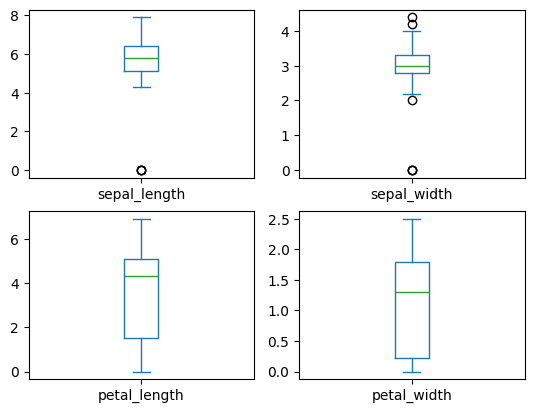

In [ ]:
from matplotlib import pyplot

iris_df.plot(kind='box', subplots=True, layout=(2,2), sharex=False, sharey=False)

pyplot.show()

#### Penjelasan

Kita dapat menggunakan matplotlib untuk memvisualisasikan data dalam bentuk grafik. Pertama, `pyplot` di-import dari library `matplotlib` untuk menampilkan plot. Kemudian, `iris_df.plot()` digunakan untuk membuat visualisasi dengan tipe box plot, di mana setiap variabel ditampilkan dalam subplot terpisah. Parameter `subplots=True` membuat tiap kolom memiliki plot sendiri, `layout=(2,2)` mengatur susunan plot dalam 2 baris dan 2 kolom, serta `sharex=False` dan `sharey=False` membuat setiap plot memiliki skala sumbu yang independen. Terakhir, `pyplot.show()` digunakan untuk menampilkan seluruh grafik yang telah dibuat.


### Histogram

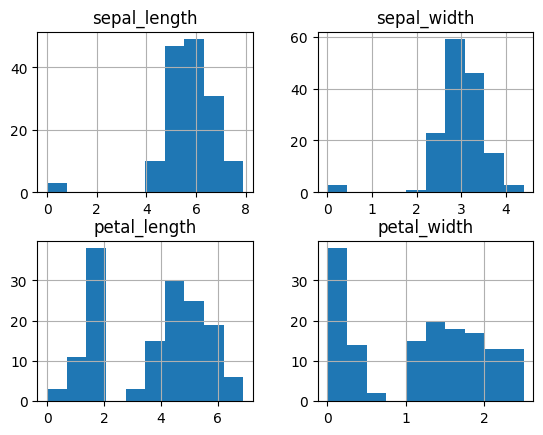

In [ ]:
iris_df.hist()
pyplot.show()

#### Penjelasan

Kita dapat menggunakan pandas untuk membuat visualisasi distribusi data dalam bentuk histogram. Method `iris_df.hist()` digunakan untuk menampilkan histogram dari setiap variabel numerik dalam DataFrame, sehingga kita dapat melihat sebaran nilai pada masing-masing fitur. Setelah itu, `pyplot.show()` digunakan untuk menampilkan seluruh grafik yang telah dibuat.


### Scatter Plot Matrix

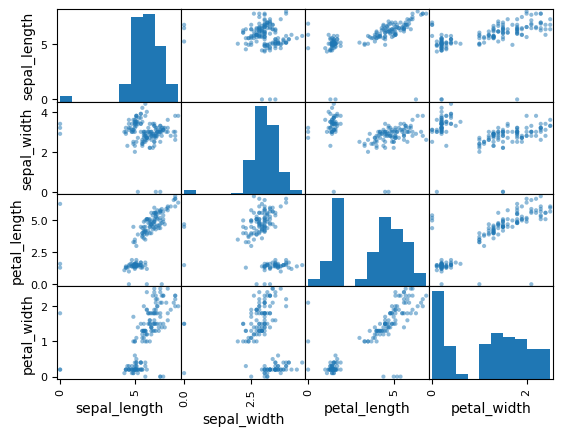

In [ ]:
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt

scatter_matrix(iris_df)
plt.show()

#### Penjelasan

Kita dapat menggunakan scatter matrix untuk melihat hubungan antar variabel dalam dataset. Pertama, fungsi `scatter_matrix` di-import dari `pandas.plotting` dan `matplotlib.pyplot` di-import sebagai `plt` untuk menampilkan grafik. Kemudian, `scatter_matrix(iris_df)` digunakan untuk membuat plot berupa matriks yang menampilkan scatter plot untuk setiap pasangan variabel, serta histogram pada diagonalnya. Dengan visualisasi ini, kita dapat melihat pola hubungan atau korelasi antar fitur. Terakhir, `plt.show()` digunakan untuk menampilkan grafik tersebut.


## Tugas
1. Download Glass dataset dari https://archive.ics.uci.edu/dataset/42/glass+identification
2. Masukkan data Glass ke dataframe menggunakan Pandas.
3. Tampilkan 10 data pertama.
4. Hitung rata-rata nilai per variabel untuk setiap data.
5. Hitung rata-rata nilai per variabel dikelompokkan berdasarkan `Type`.
6. Buatlah plot bertipe 'line' untuk masing-masing variabelnya menggunakan Pandas Plot.

In [ ]:
# nomor 1
! wget https://archive.ics.uci.edu/static/public/42/glass+identification.zip
! unzip glass+identification.zip
! ls

--2026-03-19 08:02:33--  https://archive.ics.uci.edu/static/public/42/glass+identification.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘glass+identification.zip’

glass+identificatio     [ <=>                ]   6.23K  --.-KB/s    in 0s      

2026-03-19 08:02:33 (68.7 MB/s) - ‘glass+identification.zip’ saved [6380]

Archive:  glass+identification.zip
  inflating: Index                   
  inflating: glass.data              
  inflating: glass.names             
  inflating: glass.tag               
glass.data		  glass.names  Index
glass+identification.zip  glass.tag    sample_data


In [ ]:
# nomor 2
import pandas as pd
kolom = ['ID', 'RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type']
glass_df = pd.read_csv('glass.data', header=None, names=kolom)
glass_df.set_index('ID', inplace=True)

# nomor 3
print("10 Data Pertama Glass Dataset:")
print(glass_df.head(10))

10 Data Pertama Glass Dataset:
         RI     Na    Mg    Al     Si     K    Ca   Ba    Fe  Type
ID                                                                
1   1.52101  13.64  4.49  1.10  71.78  0.06  8.75  0.0  0.00     1
2   1.51761  13.89  3.60  1.36  72.73  0.48  7.83  0.0  0.00     1
3   1.51618  13.53  3.55  1.54  72.99  0.39  7.78  0.0  0.00     1
4   1.51766  13.21  3.69  1.29  72.61  0.57  8.22  0.0  0.00     1
5   1.51742  13.27  3.62  1.24  73.08  0.55  8.07  0.0  0.00     1
6   1.51596  12.79  3.61  1.62  72.97  0.64  8.07  0.0  0.26     1
7   1.51743  13.30  3.60  1.14  73.09  0.58  8.17  0.0  0.00     1
8   1.51756  13.15  3.61  1.05  73.24  0.57  8.24  0.0  0.00     1
9   1.51918  14.04  3.58  1.37  72.08  0.56  8.30  0.0  0.00     1
10  1.51755  13.00  3.60  1.36  72.99  0.57  8.40  0.0  0.11     1


In [ ]:
# nomor 4
print("Rata-rata Nilai Per Variabel:")
print(glass_df.drop(columns=['Type']).mean())

# nomor 5
print("\nRata-rata Nilai Per Variabel Berdasarkan Type:")
print(glass_df.groupby('Type').mean())

Rata-rata Nilai Per Variabel:
RI     1.518365
Na    13.407850
Mg     2.684533
Al     1.444907
Si    72.650935
K      0.497056
Ca     8.956963
Ba     0.175047
Fe     0.057009
dtype: float64

Rata-rata Nilai Per Variabel Berdasarkan Type:
            RI         Na        Mg        Al         Si         K         Ca  \
Type                                                                            
1     1.518718  13.242286  3.552429  1.163857  72.619143  0.447429   8.797286   
2     1.518619  13.111711  3.002105  1.408158  72.598026  0.521053   9.073684   
3     1.517964  13.437059  3.543529  1.201176  72.404706  0.406471   8.782941   
5     1.518928  12.827692  0.773846  2.033846  72.366154  1.470000  10.123846   
6     1.517456  14.646667  1.305556  1.366667  73.206667  0.000000   9.356667   
7     1.517116  14.442069  0.538276  2.122759  72.965862  0.325172   8.491379   

            Ba        Fe  
Type                      
1     0.012714  0.057000  
2     0.050263  0.079737  
3     

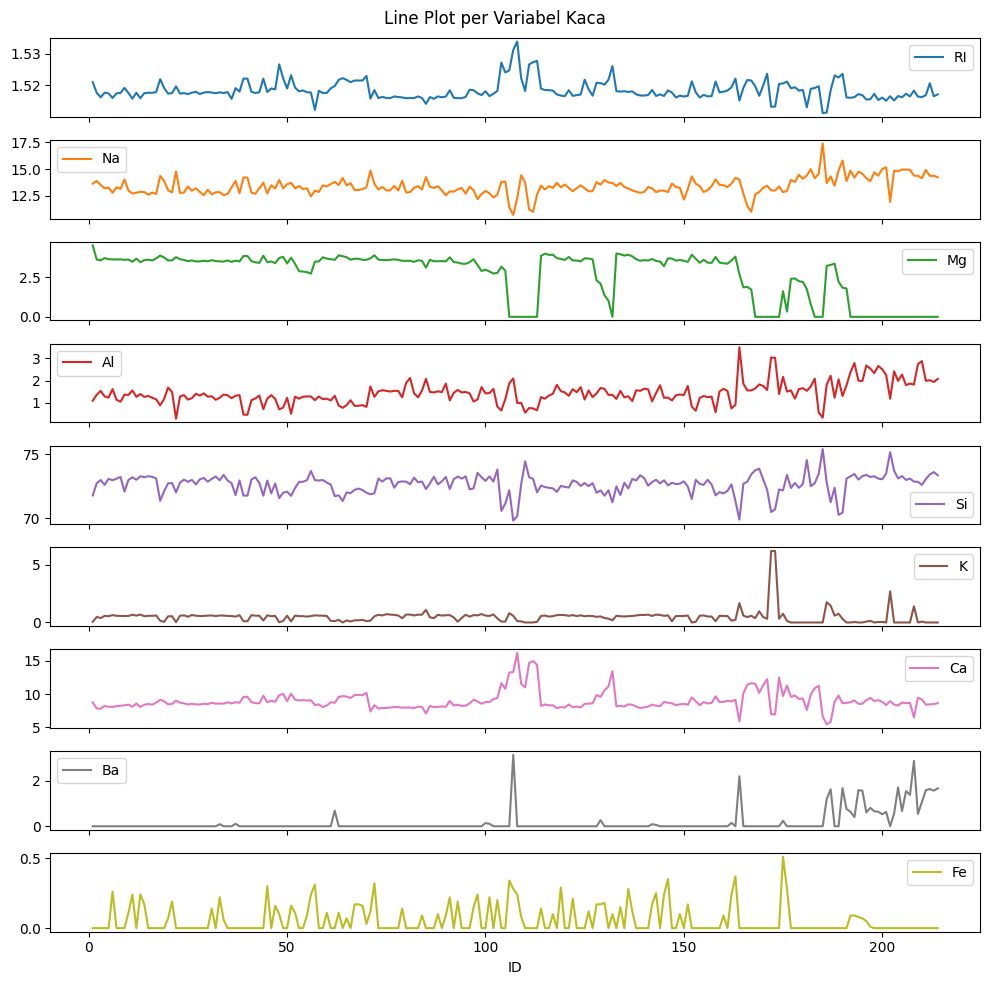

In [ ]:
# nomor 6
import matplotlib.pyplot as plt
glass_df.drop(columns=['Type']).plot(kind='line', subplots=True, figsize=(10, 10), title="Line Plot per Variabel Kaca")
plt.tight_layout()
plt.show()

### Penjelasan

1. Untuk dapat mengunduh dataset Glass, kita harus mendapatkan link downloadnya terlebih dahulu dengan cara klik kanan pada tombol 'Download' dalam website yang disediakan, lalu pilih opsi 'Copy link address'. Setelah itu, tempel link setelah perintah `! wget` agar dataset langsung diunduh di dalam Google Colab. Namun, karena file masih dalam format .zip, kita perlu mengekstrak file tersebut dengan perintah `! unzip`. File dataset yang akan digunakan dalam soal ini adalah `glass.data`.

2. Kita akan menggunakan pandas untuk memasukkan data Glass ke DataFrame. Pertama, library `pandas` di-import sebagai `pd`, lalu dibuat list `kolom` yang berisi nama-nama kolom dataset. Selanjutnya, file `glass.data` dibaca menggunakan `pd.read_csv()` tanpa header (`header=None`) dan langsung diberi nama kolom sesuai list tersebut. Terakhir, kolom `ID` dijadikan sebagai index DataFrame dengan `set_index()` agar tidak lagimenjadi kolom biasa melainkan penanda baris data.

3. Untuk dapat menampilkan 10 data pertama dari dataset Glass, kita dapat menggunakan fungsi head() bawaan pandas dengan membawa nilai parameter 10 (`glass_df.head(10)`). Hasilnya, program akan mencetak 10 data pertama dari dataset Glass.

4. Fungsi `mean()` dari pandas dapat digunakan untuk mencari nilai rata-rata per variabel dari setiap data. Namun, sebelum fungsi ini digunakan, fungsi drop akan dipanggil terlebih dahulu dengan membawa kolom 'Type' agar nilai dari Type tidak ikut dihitung sebagai rata-rata (`glass_df.drop(columns=['Type']).mean()`). Hasilnya, program akan menampilkan nilai rata-rata dari setiap variabel.

5. Fungsi `mean()` masih digunakan untuk mencari nilai rata-rata dari setiap variabel, namun ditambahkan fungsi `groupby()` dengan membawa parameter 'Type' agar nilai rata-rata yang ditampilkan dapat dikelompokkan berdasarkan nilai 'Type'.

6. Kode ini digunakan untuk membuat visualisasi data dalam bentuk line plot untuk setiap variabel. Pertama, `matplotlib.pyplot` di-import sebagai `plt`. Kemudian, `glass_df.drop(columns=['Type'])` digunakan untuk menghapus kolom `Type` agar tidak ikut diplot. Selanjutnya, `.plot()` dengan `kind='line'` dan `subplots=True` membuat grafik garis terpisah untuk tiap variabel, dengan ukuran gambar diatur melalui `figsize`. Setelah itu, `plt.tight_layout()` digunakan agar tata letak plot tidak saling bertumpuk. Terakhir, `plt.show()` menampilkan seluruh grafik yang telah dibuat.
